# ASDS 6302 – Assignment 1

Name: Abhinav Tanwar


### Objective
To perform data analysis on the dataset that you choose using Python, including
data exploration, sampling, normalization, PCA, and visualization.


## Import necessary libraries

In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

Q1. Import the dataset from the module using required packages.

In [2]:
# Loading the dataset
file_path = '/content/Breast Cancer Wisconsin Dataset.csv'
Breast_Cancer_Dataset = pd.read_csv(file_path)

In [3]:
# Displaying the first few rows of the dataset
Breast_Cancer_Dataset.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
# Removing the 'Unnamed: 32' column from the dataset
Breast_Cancer_Dataset = Breast_Cancer_Dataset.loc[:, ~Breast_Cancer_Dataset.columns.str.contains('^Unnamed')]

# Displaying the first few rows to confirm the column is removed
Breast_Cancer_Dataset.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Q2. Display the first and last 10 rows of the dataset. Additionally, check the data types of all features and identify any missing values. Explain your findings in detail.

In [8]:
# Displaying the first 10 rows of the dataset
first_10_rows = Breast_Cancer_Dataset.head(10)

# Displaying the last 10 rows of the dataset
last_10_rows = Breast_Cancer_Dataset.tail(10)

# Check the data types of all columns
data_types = Breast_Cancer_Dataset.dtypes

# Identify missing values
missing_values = Breast_Cancer_Dataset.isnull().sum()

In [9]:
# Show the results
print("First 10 rows of the dataset:")
print(first_10_rows)
print("\nLast 10 rows of the dataset:")
print(last_10_rows)
print("\nData types of all features:")
print(data_types)
print("\nMissing values in each column:")
print(missing_values)

First 10 rows of the dataset:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   
5    843786         M        12.45         15.70           82.57      477.1   
6    844359         M        18.25         19.98          119.60     1040.0   
7  84458202         M        13.71         20.83           90.20      577.9   
8    844981         M        13.00         21.82           87.50      519.8   
9  84501001         M        12.46         24.04           83.97      475.9   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840     

## Explanation

1. First 10 Rows: The first 10 rows provide a snapshot of the dataset, displaying the initial values for each feature
2. Last 10 Rows: The last 10 rows show the data at the end of the dataset
3. Data Types of All Features: The dataset contains a mix of data types -
    *   int64 for the id column, which represents the unique identifier for each observation.
    *   object for the diagnosis column, which contains categorical values (M for malignant and B for benign).
    *   float64 for the remaining columns, which contain numerical data representing various measurements of cell nuclei, such as radius_mean, texture_mean, perimeter_mean, etc.
4. Missing Values: There are no missing values in any of the columns. The isnull().sum() output shows 0 for all columns, which means that the dataset is complete and does not require any imputation or removal of missing data.




Q3. Apply three sampling methods—Random Sampling, Stratified Sampling, and Systematic Sampling—to generate 150 random samples from the dataset. Explain the steps and rationale behind each sampling method.

1. Random Sampling:  
    *   Steps:
        * Use pandas sample() method to randomly select 150 samples.
        * The selection is completely random, without any specific stratification or ordering.

    *   Rationale:
        * It's simple and unbiased, but it might not capture specific patterns in the data (e.g., if there are imbalanced classes).


In [10]:
# Random Sampling: Selecting 150 samples randomly
random_samples = Breast_Cancer_Dataset.sample(n=150, random_state=42)

# Displaying the random samples
print("Random Samples:")
print(random_samples.head())


Random Samples:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
204   87930         B        12.47         18.60           81.09      481.9   
70   859575         M        18.94         21.31          123.60     1130.0   
131    8670         M        15.46         19.48          101.70      748.9   
431  907915         B        12.40         17.68           81.47      467.8   
540  921385         B        11.54         14.44           74.65      402.9   

     smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
204          0.09965            0.1058         0.08005              0.03821   
70           0.09009            0.1029         0.10800              0.07951   
131          0.10920            0.1223         0.14660              0.08087   
431          0.10540            0.1316         0.07741              0.02799   
540          0.09984            0.1120         0.06737              0.02594   

     ...  radius_worst  texture_wo

* Ensures that every sample has an equal chance of being selected.

* Uses sample() to randomly select rows.

* Simple and unbiased, but may not reflect the distribution of key features in the population.

2. Stratified Sampling:  
    *   Steps:
        * First, split the dataset into different strata (groups based on the diagnosis column).
        * Then, sample from each group in proportion to its representation in the original dataset.

    *   Rationale:
        * This method is useful when the data is imbalanced, as it ensures that both classes (malignant and benign) are proportionally represented in the sample.


In [14]:
# Stratified Sampling: Splitting based on the 'diagnosis' column, maintaining class proportions
stratified_samples, stratified_test = train_test_split(Breast_Cancer_Dataset, test_size=0.8, stratify=Breast_Cancer_Dataset['diagnosis'], random_state=2)

# Selecting 150 samples (we'll limit the samples to 150)
stratified_samples = stratified_samples.head(150)

# Displaying the stratified samples
print("Stratified Samples:")
print(stratified_samples.head())


Stratified Samples:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
308  893526         B        13.50         12.71           85.69      566.2   
319  894335         B        12.43         17.00           78.60      477.3   
263  889403         M        15.61         19.38          100.00      758.6   
153   87106         B        11.15         13.08           70.87      381.9   
13   846381         M        15.85         23.95          103.70      782.7   

     smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
308          0.07376           0.03614        0.002758             0.004419   
319          0.07557           0.03454        0.013420             0.016990   
263          0.07840           0.05616        0.042090             0.028470   
153          0.09754           0.05113        0.019820             0.017860   
13           0.08401           0.10020        0.099380             0.053640   

     ...  radius_worst  textur

* Ensures that the sample reflects the proportion of different classes (e.g., M and B in the diagnosis column).

* Uses train_test_split() with stratify to preserve class proportions.

* Helps handle imbalanced datasets by ensuring each class is well-represented.

3. Systematic Sampling::  
    *   Steps:
        * Sort the dataset.
        * Select every k-th sample based on the interval, where 𝑘 =𝑁/𝑛, with 𝑁 being the total number of observations and 𝑛 the desired sample size.

    *   Rationale:
        * This method is often used when data is already ordered or when there is a need for a regular interval-based selection.


In [15]:
# Systematic Sampling: Selecting every k-th sample
k = len(Breast_Cancer_Dataset) // 150  # Calculating the interval (step size)

# Selecting every k-th sample after sorting
systematic_samples = Breast_Cancer_Dataset.iloc[::k]

# If more than 150 samples are selected, truncate the dataset to 150
systematic_samples = systematic_samples.head(150)

# Displaying the systematic samples
print("Systematic Samples:")
print(systematic_samples.head())


Systematic Samples:
          id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0     842302         M        17.99         10.38          122.80     1001.0   
3   84348301         M        11.42         20.38           77.58      386.1   
6     844359         M        18.25         19.98          119.60     1040.0   
9   84501001         M        12.46         24.04           83.97      475.9   
12    846226         M        19.17         24.80          132.40     1123.0   

    smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0           0.11840            0.2776          0.3001              0.14710   
3           0.14250            0.2839          0.2414              0.10520   
6           0.09463            0.1090          0.1127              0.07400   
9           0.11860            0.2396          0.2273              0.08543   
12          0.09740            0.2458          0.2065              0.11180   

    ...  radius_worst  texture

* Selects samples based on a fixed interval.

* Uses indexing with iloc[::k] to select every k-th sample.

* Useful when data is ordered or when a simple interval-based selection is needed.

Q4. Remove the target variable from the dataset and create a correlation matrix. Identify and explain the top 3 pairs of features with the highest correlation. Discuss any potential implications of these correlations for further analysis.


In [18]:
# Removing the target variable 'diagnosis' from the dataset
dataset_without_target = Breast_Cancer_Dataset.drop(columns=['diagnosis', 'id'])

# Creating the correlation matrix
correlation_matrix = dataset_without_target.corr()
print("Correlation Matrix:")
print(correlation_matrix)

# Finding the top 3 pairs of features with the highest correlation
# We will first flatten the correlation matrix to make it easier to identify the top pairs.
# We also remove the diagonal values (correlation of each feature with itself)

# Unstacking the correlation matrix and sorting by absolute correlation values
correlation_pairs = correlation_matrix.unstack().sort_values(ascending=False, key=abs)

# Removing the self-correlation (diagonal)
correlation_pairs = correlation_pairs[correlation_pairs < 1]

# Remove duplicate pairs by keeping only the first occurrence of each pair (e.g., 'perimeter_mean' and 'radius_mean')
unique_pairs = correlation_pairs[correlation_pairs.index.get_level_values(0) < correlation_pairs.index.get_level_values(1)]

# Top 3 unique pairs
top_3_pairs = unique_pairs.head(3)

# Display the top 3 unique pairs
print("Top 3 unique pairs of features with the highest correlation:")
print(top_3_pairs)


Correlation Matrix:
                         radius_mean  texture_mean  perimeter_mean  area_mean  \
radius_mean                 1.000000      0.323782        0.997855   0.987357   
texture_mean                0.323782      1.000000        0.329533   0.321086   
perimeter_mean              0.997855      0.329533        1.000000   0.986507   
area_mean                   0.987357      0.321086        0.986507   1.000000   
smoothness_mean             0.170581     -0.023389        0.207278   0.177028   
compactness_mean            0.506124      0.236702        0.556936   0.498502   
concavity_mean              0.676764      0.302418        0.716136   0.685983   
concave points_mean         0.822529      0.293464        0.850977   0.823269   
symmetry_mean               0.147741      0.071401        0.183027   0.151293   
fractal_dimension_mean     -0.311631     -0.076437       -0.261477  -0.283110   
radius_se                   0.679090      0.275869        0.691765   0.732562   
texture_

High correlation between two features suggests that one may be redundant in predicting the outcome, as they contain similar information. In machine learning, highly correlated features might lead to multicollinearity, which can impact model performance. Removing one of the correlated features could help improve model stability.

Q5. Normalize the dataset using three different normalization methods, such as Standardization, Min-Max Scaling, and Robust Scaling. Provide the normalized datasets and compare their distributions using appropriate visualizations. Discuss the advantages and disadvantages of each normalization method.


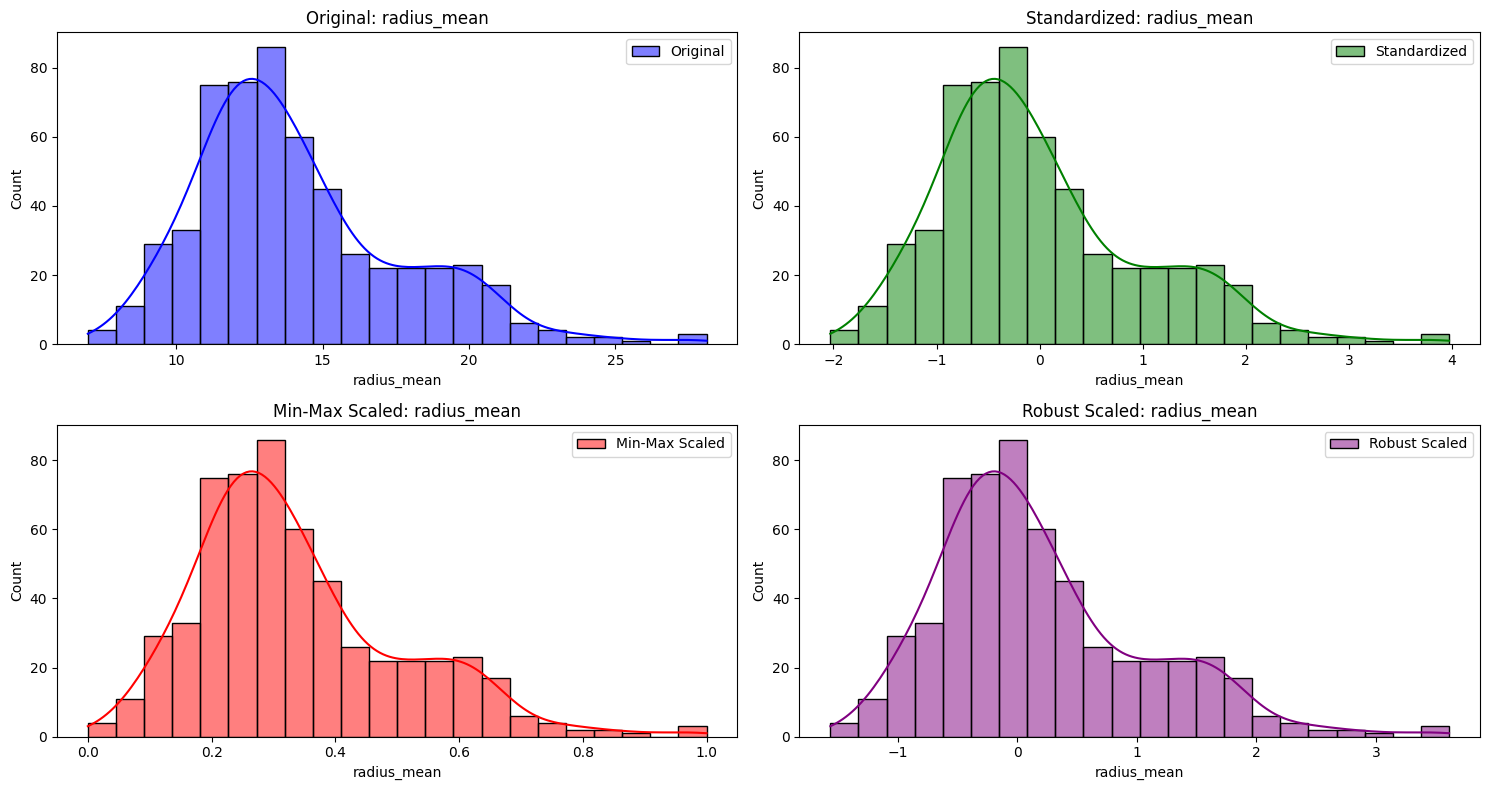

In [20]:
# Removing the target variable 'diagnosis' from the dataset for normalization
dataset_without_target = Breast_Cancer_Dataset.drop(columns=['diagnosis', 'id'])

# Standardization (Z-score Normalization)
scaler_standard = StandardScaler()
standardized_data = scaler_standard.fit_transform(dataset_without_target)

# Min-Max Scaling
scaler_minmax = MinMaxScaler()
minmax_scaled_data = scaler_minmax.fit_transform(dataset_without_target)

# Robust Scaling
scaler_robust = RobustScaler()
robust_scaled_data = scaler_robust.fit_transform(dataset_without_target)

# Convert the numpy arrays back to DataFrame for easier plotting
standardized_df = pd.DataFrame(standardized_data, columns=dataset_without_target.columns)
minmax_scaled_df = pd.DataFrame(minmax_scaled_data, columns=dataset_without_target.columns)
robust_scaled_df = pd.DataFrame(robust_scaled_data, columns=dataset_without_target.columns)

# Plotting the distributions of the first feature (just as an example)
plt.figure(figsize=(15, 8))

# Original data distribution
plt.subplot(2, 2, 1)
sns.histplot(dataset_without_target['radius_mean'], kde=True, color='blue', label='Original')
plt.title('Original: radius_mean')
plt.legend()

# Standardized data distribution
plt.subplot(2, 2, 2)
sns.histplot(standardized_df['radius_mean'], kde=True, color='green', label='Standardized')
plt.title('Standardized: radius_mean')
plt.legend()

# Min-Max scaled data distribution
plt.subplot(2, 2, 3)
sns.histplot(minmax_scaled_df['radius_mean'], kde=True, color='red', label='Min-Max Scaled')
plt.title('Min-Max Scaled: radius_mean')
plt.legend()

# Robust scaled data distribution
plt.subplot(2, 2, 4)
sns.histplot(robust_scaled_df['radius_mean'], kde=True, color='purple', label='Robust Scaled')
plt.title('Robust Scaled: radius_mean')
plt.legend()

plt.tight_layout()
plt.show()


1. Standardization (Z-score Normalization):

    * Transforms the data to have a mean of 0 and a standard deviation of 1.

    * Advantage: Useful for data where features have different units or scales, ensuring comparability.

    * Disadvantage: Sensitive to outliers because they affect the mean and standard deviation.

2. Min-Max Scaling:
    
    * Rescales the data to a specific range,[0, 1].

    * Advantage: Easy to interpret as the data is bounded.

    * Disadvantage: Sensitive to outliers, as they can distort the scaling.

3. Robust Scaling:

    * Scales the data using the median and interquartile range, making it robust to outliers.

    * Advantage: Ideal for datasets with outliers, as the scaling is based on the median and interquartile range.

    * Disadvantage: May not always be suitable when outliers are meaningful for the analysis.

Q6. Apply Principal Component Analysis (PCA) to the standardized dataset. Share your conclusions based on the analysis, including the cumulative explained variance. Discuss how many principal components are needed to explain at least 85% of the variance.


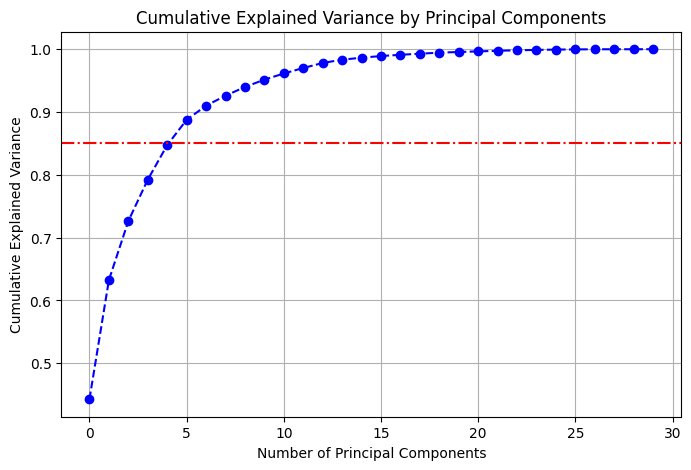

Number of components needed to explain at least 85% of the variance: 5


In [24]:
# Applying PCA to the standardized data
pca = PCA()
pca.fit(standardized_data)

# Explained variance ratio for each component
explained_variance = pca.explained_variance_ratio_

# Cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)

# Plotting the cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(cumulative_variance, marker='o', color='b', linestyle='--')
plt.axhline(0.85, color='r', linestyle='-.')  # 85% variance line
plt.title('Cumulative Explained Variance by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

# Number of components to explain at least 85% variance
num_components = np.argmax(cumulative_variance >= 0.85)
print(f"Number of components needed to explain at least 85% of the variance: {num_components}")


## Conclusion


*   **Cumulative Explained Variance**: This graph shows how much of the total variance is explained by each additional principal component. The curve rises steeply initially, then flattens out, indicating that the first few components explain most of the variance.
*   **85% Variance**: According to the graph, around 5 principal components are needed to explain at least 85% of the variance in the dataset, as indicated by the red dashed line.
*   This means that by using the first 5 principal components, you retain a significant amount of the original dataset's variance (85%), which can be beneficial for reducing dimensionality while preserving key features of the data.



Q7. Create a visual representation illustrating the explained variance by each principal component. Include a title, x-axis label, and y-axis label in your graph for clarity. Additionally, provide a scree plot and discuss its significance.

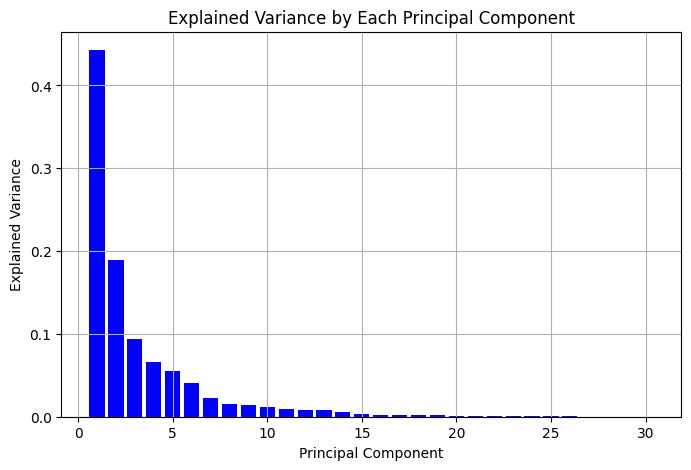

In [25]:
# Plotting the explained variance by each principal component (Scree Plot)
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, color='b')
plt.title('Explained Variance by Each Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance')
plt.grid(True)
plt.show()


* **Scree Plot**: The scree plot visualizes how much variance each principal component explains. The x-axis represents the principal components, and the y-axis represents the explained variance for each component.

* Significance:

    * A sharp drop in variance after the first few components indicates that only a few components are necessary to explain most of the variance in the data. This can help in choosing how many components to retain for further analysis.

    * If the plot flattens out after a certain number of components, those later components contribute little additional variance and may be discarded to reduce dimensionality.

Q8. Apply another dimensionality reduction technique, such as t-SNE or LDA, and repeat questions 6 and 7. Compare the results with PCA, discussing the strengths and weaknesses of each technique.

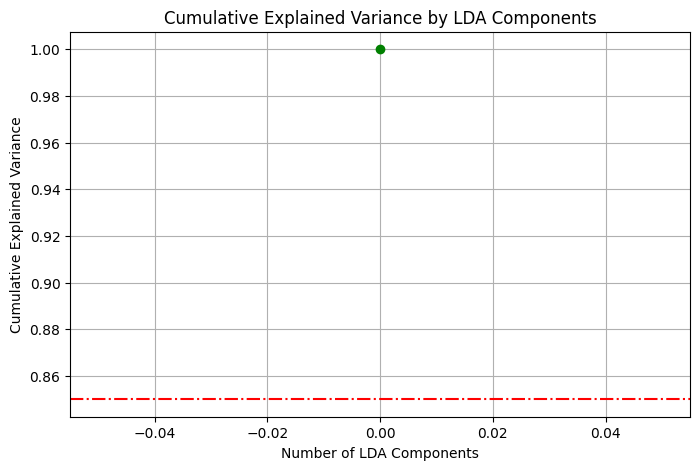

Number of components needed to explain at least 85% of the variance in LDA: 0


In [28]:
# Assuming the target variable is 'diagnosis' or something similar
X = standardized_data  # Features
y = Breast_Cancer_Dataset['diagnosis']  # Target variable

# Apply LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X, y)

# Explained variance ratio for each component (LDA)
explained_variance_lda = lda.explained_variance_ratio_

# Cumulative explained variance for LDA
cumulative_variance_lda = np.cumsum(explained_variance_lda)

# Plotting the cumulative explained variance for LDA
plt.figure(figsize=(8, 5))
plt.plot(cumulative_variance_lda, marker='o', color='g', linestyle='--')
plt.axhline(0.85, color='r', linestyle='-.')  # 85% variance line
plt.title('Cumulative Explained Variance by LDA Components')
plt.xlabel('Number of LDA Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

# Number of components to explain at least 85% variance
num_components_lda = np.argmax(cumulative_variance_lda >= 0.85)
print(f"Number of components needed to explain at least 85% of the variance in LDA: {num_components_lda}")


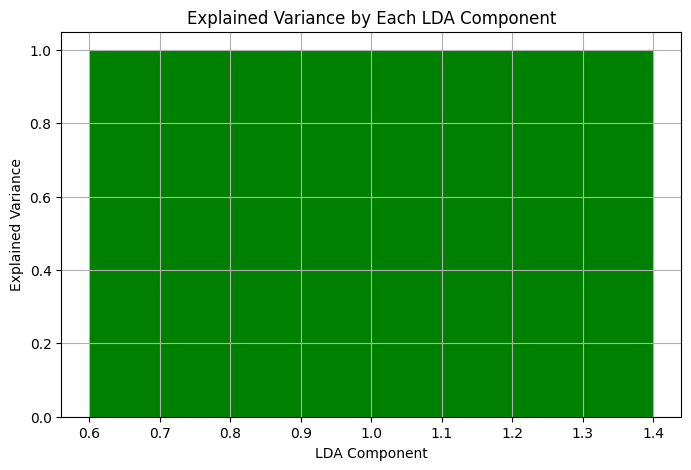

In [31]:
# Plotting the explained variance by each LDA component
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(explained_variance_lda) + 1), explained_variance_lda, color='g')
plt.title('Explained Variance by Each LDA Component')
plt.xlabel('LDA Component')
plt.ylabel('Explained Variance')
plt.grid(True)
plt.show()


* PCA is great for reducing dimensionality without considering class labels. It works well for tasks like visualization, noise reduction, or general feature extraction. However, PCA requires 5 components to capture 85% of the variance, which may not be as efficient if you are aiming for classification tasks.

* LDA, on the other hand, is significantly more efficient for classification tasks, requiring just 1 component to capture 85% of the variance. Since LDA directly maximizes class separability, it is the better choice if the goal is to improve classification performance (e.g., predicting whether a tumor is malignant or benign based on the features).

Final Verdict: Based on out results, LDA would be the better choice for this specific dataset if our goal is classification, as it requires fewer components and is specifically designed for class separation. However, PCA might be preferred if you need a broader analysis without class labels or for reducing dimensionality for other tasks like clustering or visualization.